In [1]:
# =========================================================
# UK HOUSING AFFORDABILITY - EDA SCRIPT
# =========================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
# MOUNT DRIVE

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted.")


Mounted at /content/drive


In [2]:
# =========================================================
# 1. DEFINE PROJECT PATHS
# =========================================================

project_path = "/content/drive/MyDrive/DataAnalytics/UKHousingAffordabilityAnalysis"

data_path = os.path.join(project_path, "Data")
processed_data_path = os.path.join(data_path, "Processed")

outputs_path = os.path.join(project_path, "Outputs")
figures_path = os.path.join(outputs_path, "Figures")
tables_path = os.path.join(outputs_path, "Tables")

os.makedirs(figures_path, exist_ok=True)
os.makedirs(tables_path, exist_ok=True)


In [3]:
# =========================================================
# 2. LOAD PROCESSED DATASET
# =========================================================

file_path = os.path.join(
    processed_data_path,
    "UKHousingAffordabilityDataset.csv"
)

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Dataset loaded successfully.
Shape: (7255, 10)

Columns:
['Local authority code', 'Local authority name', 'Year', 'Median_House_Price', 'Median_Earnings', 'Affordability_Ratio_Earnings', 'Region code', 'Region name', 'Affordability_Ratio_Income', 'Affordability_Gap']


In [4]:
# =========================================================
# 3. DATA TYPE CHECK / FINAL CLEANUP
# =========================================================

numeric_cols = [
    "Year",
    "Median_House_Price",
    "Median_Earnings",
    "Affordability_Ratio_Earnings",
    "Affordability_Ratio_Income",
    "Affordability_Gap"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

# Optional: create comparison-only subset for analyses requiring both ratios
comparison_df = df.dropna(
    subset=["Affordability_Ratio_Income", "Affordability_Gap"]
).copy()

latest_year = int(df["Year"].max())
latest_df = df[df["Year"] == latest_year].copy()


Data types:
Local authority code             object
Local authority name             object
Year                              int64
Median_House_Price                int64
Median_Earnings                 float64
Affordability_Ratio_Earnings    float64
Region code                      object
Region name                      object
Affordability_Ratio_Income      float64
Affordability_Gap               float64
dtype: object

Missing values:
Local authority code             0
Local authority name             0
Year                             0
Median_House_Price               0
Median_Earnings                  0
Affordability_Ratio_Earnings     0
Region code                      0
Region name                      0
Affordability_Ratio_Income      29
Affordability_Gap               29
dtype: int64


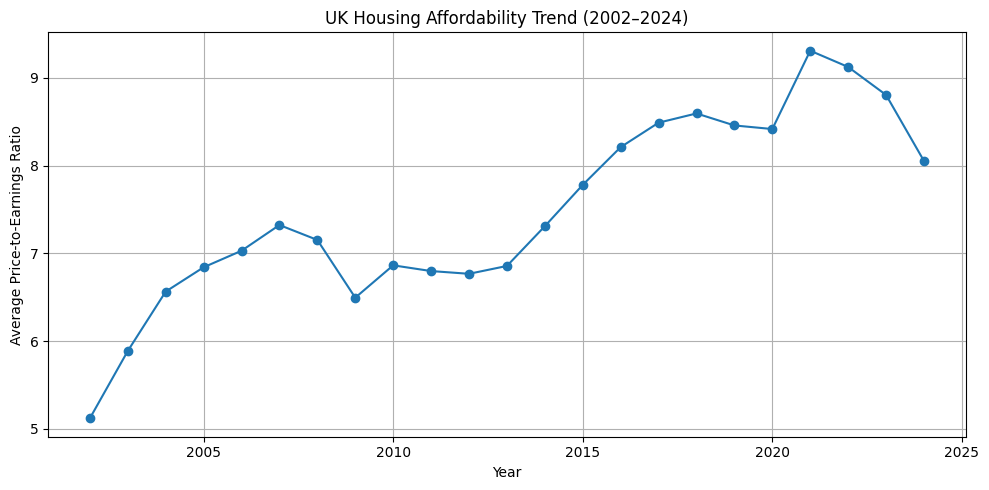

In [5]:
# =========================================================
# 4. EDA 1 — NATIONAL AFFORDABILITY TREND
# =========================================================

uk_trend = df.groupby("Year")["Affordability_Ratio_Earnings"].mean()

plt.figure(figsize=(10, 5))
plt.plot(uk_trend.index, uk_trend.values, marker="o")
plt.title("UK Housing Affordability Trend (2002–2024)")
plt.xlabel("Year")
plt.ylabel("Average Price-to-Earnings Ratio")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "EDA_01_UK_Affordability_Trend.png"))
plt.show()

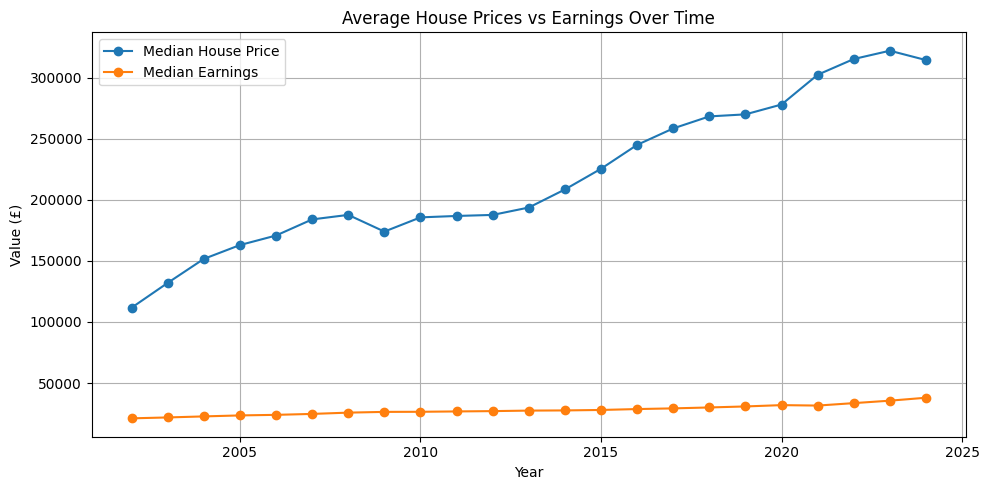

In [6]:
# =========================================================
# 5. EDA 2 — HOUSE PRICES VS EARNINGS TREND
# =========================================================

price_trend = df.groupby("Year")["Median_House_Price"].mean()
earnings_trend = df.groupby("Year")["Median_Earnings"].mean()

plt.figure(figsize=(10, 5))
plt.plot(price_trend.index, price_trend.values, marker="o", label="Median House Price")
plt.plot(earnings_trend.index, earnings_trend.values, marker="o", label="Median Earnings")
plt.title("Average House Prices vs Earnings Over Time")
plt.xlabel("Year")
plt.ylabel("Value (£)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "EDA_02_House_Prices_vs_Earnings.png"))
plt.show()

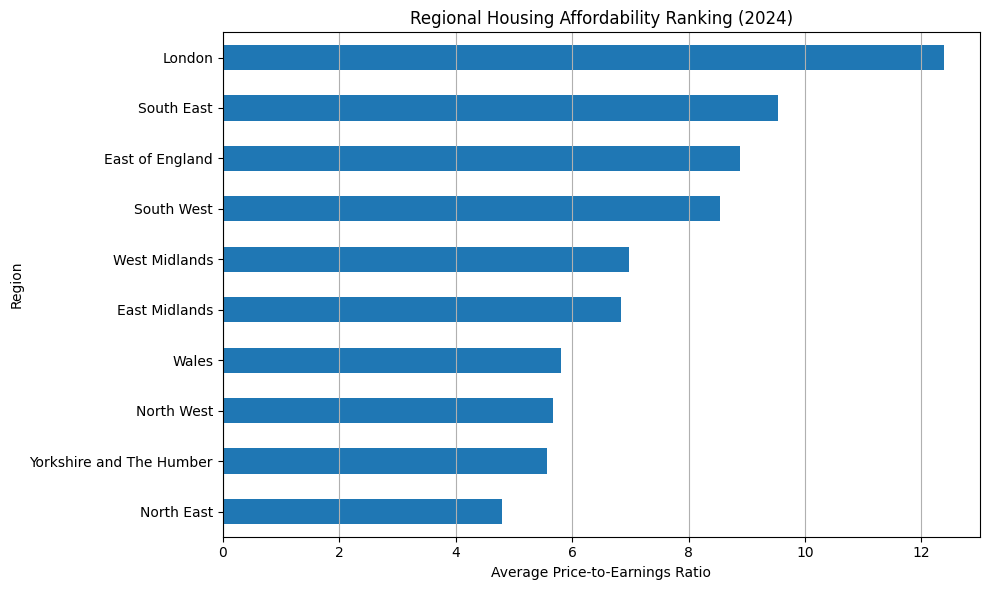

In [7]:
# =========================================================
# 6. EDA 3 — REGIONAL AFFORDABILITY RANKING (LATEST YEAR)
# =========================================================

regional_affordability = (
    latest_df.groupby("Region name")["Affordability_Ratio_Earnings"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
regional_affordability.plot(kind="barh")
plt.title(f"Regional Housing Affordability Ranking ({latest_year})")
plt.xlabel("Average Price-to-Earnings Ratio")
plt.ylabel("Region")
plt.grid(axis="x")
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "EDA_03_Regional_Affordability_Ranking.png"))
plt.show()

regional_affordability.to_csv(
    os.path.join(tables_path, "EDA_03_Regional_Affordability_Ranking.csv")
)


In [8]:

# =========================================================
# 7. EDA 4 — TOP 10 LEAST AFFORDABLE LOCAL AUTHORITIES
# =========================================================

top10_unaffordable = (
    latest_df[
        ["Local authority name", "Region name", "Affordability_Ratio_Earnings"]
    ]
    .sort_values("Affordability_Ratio_Earnings", ascending=False)
    .head(10)
)

print("\nTop 10 Least Affordable Local Authorities:")
print(top10_unaffordable)

top10_unaffordable.to_csv(
    os.path.join(tables_path, "EDA_04_Top10_Least_Affordable_Areas.csv"),
    index=False
)


Top 10 Least Affordable Local Authorities:
        Local authority name Region name  Affordability_Ratio_Earnings
7129  Kensington and Chelsea      London                         22.80
7142             Westminster      London                         18.31
7116                  Camden      London                         16.84
7122  Hammersmith and Fulham      London                         15.83
7114                   Brent      London                         14.18
7112                  Barnet      London                         13.34
7128               Islington      London                         13.22
7189               Elmbridge  South East                         12.94
7141              Wandsworth      London                         12.87
7124                  Harrow      London                         12.85


In [9]:
# =========================================================
# 8. EDA 5 — TOP 10 MOST AFFORDABLE LOCAL AUTHORITIES
# =========================================================

top10_affordable = (
    latest_df[
        ["Local authority name", "Region name", "Affordability_Ratio_Earnings"]
    ]
    .sort_values("Affordability_Ratio_Earnings", ascending=True)
    .head(10)
)

print("\nTop 10 Most Affordable Local Authorities:")
print(top10_affordable)

top10_affordable.to_csv(
    os.path.join(tables_path, "EDA_05_Top10_Most_Affordable_Areas.csv"),
    index=False
)


Top 10 Most Affordable Local Authorities:
     Local authority name Region name  Affordability_Ratio_Earnings
7249        Blaenau Gwent       Wales                          3.64
6959              Burnley  North West                          3.67
6944        County Durham  North East                          4.02
6962             Hyndburn  North West                          4.07
6954            Blackpool  North West                          4.24
6949           Sunderland  North East                          4.28
7254       Merthyr Tydfil       Wales                          4.31
7243    Neath Port Talbot       Wales                          4.33
6957           Cumberland  North West                          4.36
7247    Rhondda Cynon Taf       Wales                          4.38


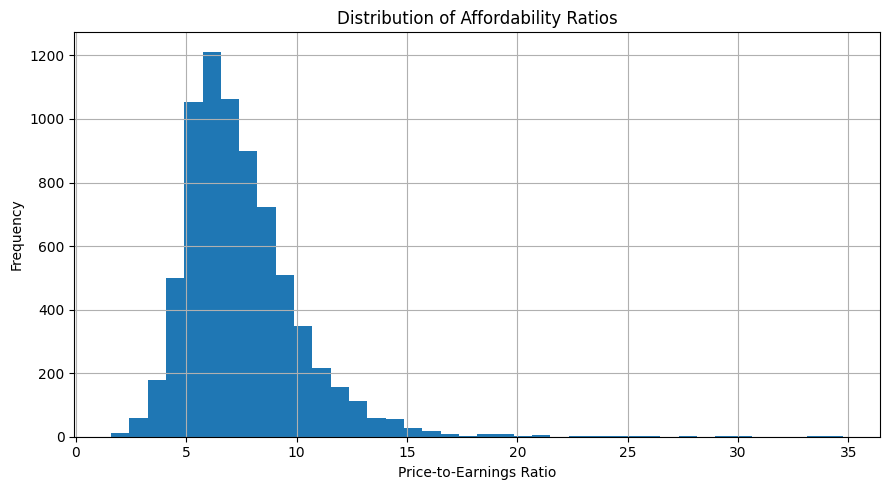

In [10]:
# =========================================================
# 9. EDA 6 — DISTRIBUTION OF AFFORDABILITY RATIOS
# =========================================================

plt.figure(figsize=(9, 5))
plt.hist(df["Affordability_Ratio_Earnings"].dropna(), bins=40)
plt.title("Distribution of Affordability Ratios")
plt.xlabel("Price-to-Earnings Ratio")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "EDA_06_Affordability_Distribution.png"))
plt.show()

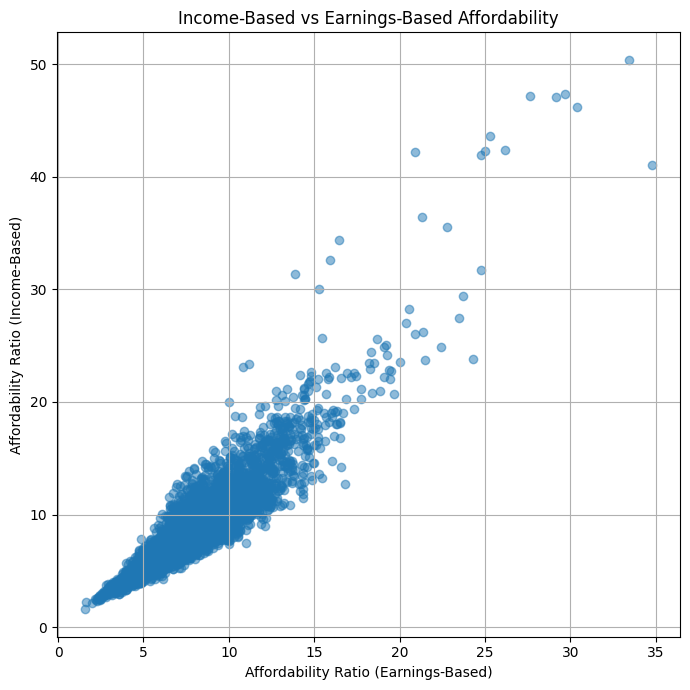

In [11]:
# =========================================================
# 10. EDA 7 — INCOME-BASED VS EARNINGS-BASED AFFORDABILITY
# =========================================================

plt.figure(figsize=(7, 7))
plt.scatter(
    comparison_df["Affordability_Ratio_Earnings"],
    comparison_df["Affordability_Ratio_Income"],
    alpha=0.5
)
plt.title("Income-Based vs Earnings-Based Affordability")
plt.xlabel("Affordability Ratio (Earnings-Based)")
plt.ylabel("Affordability Ratio (Income-Based)")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "EDA_07_Income_vs_Earnings_Affordability.png"))
plt.show()


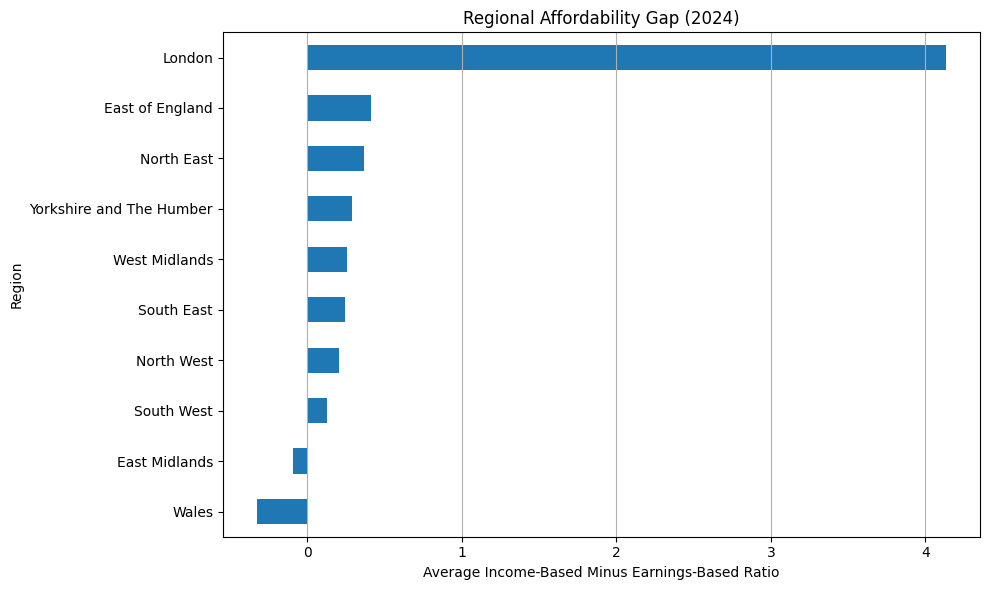

In [12]:


# =========================================================
# 11. EDA 8 — AFFORDABILITY GAP BY REGION (LATEST YEAR)
# =========================================================

regional_gap = (
    latest_df.groupby("Region name")["Affordability_Gap"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
regional_gap.plot(kind="barh")
plt.title(f"Regional Affordability Gap ({latest_year})")
plt.xlabel("Average Income-Based Minus Earnings-Based Ratio")
plt.ylabel("Region")
plt.grid(axis="x")
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "EDA_08_Regional_Affordability_Gap.png"))
plt.show()

regional_gap.to_csv(
    os.path.join(tables_path, "EDA_08_Regional_Affordability_Gap.csv")
)

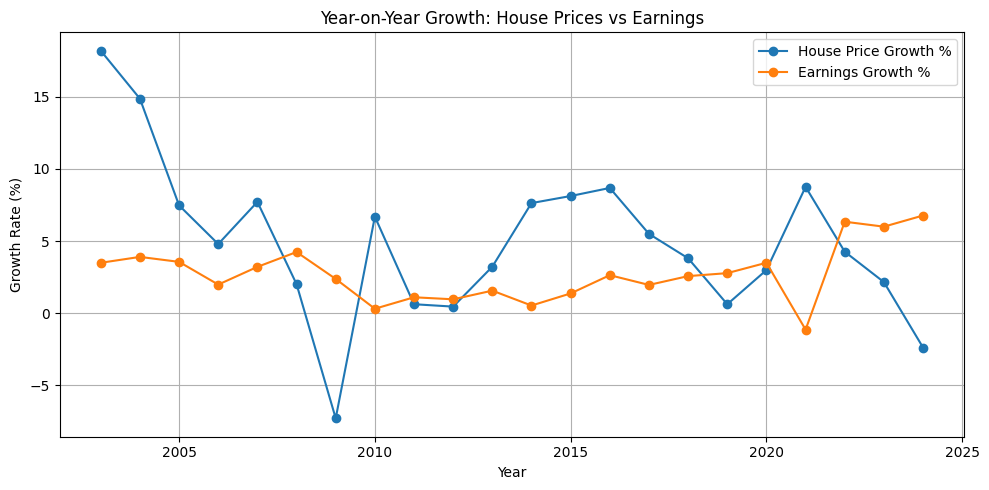

In [13]:
# =========================================================
# 12. EDA 9 — YEAR-ON-YEAR PRICE GROWTH AND EARNINGS GROWTH
# =========================================================

yearly_avg = (
    df.groupby("Year")[["Median_House_Price", "Median_Earnings"]]
    .mean()
    .reset_index()
)

yearly_avg["House_Price_Growth_Pct"] = yearly_avg["Median_House_Price"].pct_change() * 100
yearly_avg["Earnings_Growth_Pct"] = yearly_avg["Median_Earnings"].pct_change() * 100

plt.figure(figsize=(10, 5))
plt.plot(
    yearly_avg["Year"],
    yearly_avg["House_Price_Growth_Pct"],
    marker="o",
    label="House Price Growth %"
)
plt.plot(
    yearly_avg["Year"],
    yearly_avg["Earnings_Growth_Pct"],
    marker="o",
    label="Earnings Growth %"
)
plt.title("Year-on-Year Growth: House Prices vs Earnings")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "EDA_09_YoY_Growth_Prices_vs_Earnings.png"))
plt.show()

yearly_avg.to_csv(
    os.path.join(tables_path, "EDA_09_Yearly_Averages_and_Growth.csv"),
    index=False
)

In [14]:
# =========================================================
# 13. EDA 10 — SUMMARY INSIGHTS TABLE
# =========================================================

summary_insights = pd.DataFrame({
    "Metric": [
        "Dataset Rows",
        "Unique Local Authorities",
        "Unique Regions",
        "Year Start",
        "Year End",
        "Mean Affordability Ratio (Earnings-Based)",
        "Median Affordability Ratio (Earnings-Based)",
        "Mean Affordability Ratio (Income-Based)",
        "Mean Affordability Gap"
    ],
    "Value": [
        len(df),
        df["Local authority name"].nunique(),
        df["Region name"].nunique(),
        int(df["Year"].min()),
        int(df["Year"].max()),
        round(df["Affordability_Ratio_Earnings"].mean(), 2),
        round(df["Affordability_Ratio_Earnings"].median(), 2),
        round(df["Affordability_Ratio_Income"].mean(), 2),
        round(df["Affordability_Gap"].mean(), 2)
    ]
})

print("\nSummary Insights:")
print(summary_insights)

summary_insights.to_csv(
    os.path.join(tables_path, "EDA_10_Summary_Insights.csv"),
    index=False
)


Summary Insights:
                                        Metric    Value
0                                 Dataset Rows  7255.00
1                     Unique Local Authorities   318.00
2                               Unique Regions    10.00
3                                   Year Start  2002.00
4                                     Year End  2024.00
5    Mean Affordability Ratio (Earnings-Based)     7.50
6  Median Affordability Ratio (Earnings-Based)     7.02
7      Mean Affordability Ratio (Income-Based)     8.25
8                       Mean Affordability Gap     0.75
